In [68]:
import numpy as np
import matplotlib.pyplot as plt
import rtdpy
from scipy.signal import convolve

## PFR / Tanques en serie

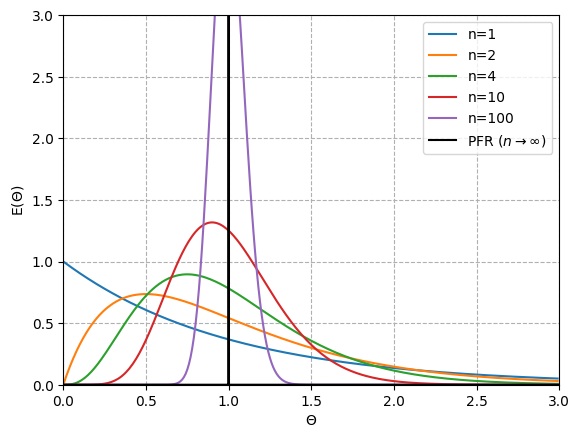

In [69]:
fig, ax = plt.subplots()
# CSTR
for n in [1, 2, 4, 10, 100]:
    a = rtdpy.Ncstr(tau=1, n=n, dt=0.01, time_end=3)
    ax.plot(a.time, a.exitage, label=f"n={n}")
# PFR
a = rtdpy.Pfr(tau=1, dt=0.001, time_end=3)
ax.plot(a.time, a.exitage, c='k', label=r"PFR ($n\rightarrow \infty$)")
ax.set_xlabel(r"$\Theta$")
ax.set_ylabel(r"E($\Theta$)")
ax.set_xlim(0, 3)
ax.set_ylim(0, 3)
ax.legend()
ax.grid(ls='--')
plt.show()

## Dispersión axial

### closed-closed

$$\frac{\partial \Psi}{\partial \Theta} = \frac{1}{\text{Pe}} \frac{\partial^2 \Psi}{\partial \lambda^2} - \frac{\partial \Psi}{\partial \lambda}$$

$$\Psi = \frac{C_T}{C_{T0}}$$

$$\lambda = \frac{z}{L}$$

$$\Theta = \frac{tU}{L}$$

$$\text{Pe} = \frac{U L}{D}$$

$$E(t) = \Psi \left( \lambda=1, t \right)$$

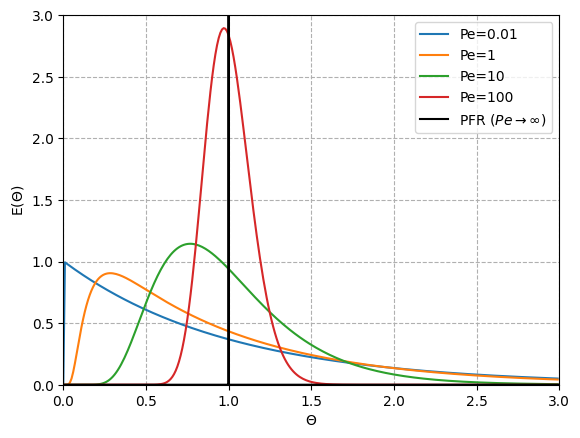

In [70]:
fig, ax = plt.subplots()

peclet = [0.01, 1, 10, 100]
for pe in peclet:
    a = rtdpy.AD_cc(tau=1, peclet=pe, dt=0.01, time_end=3)
    ax.plot(a.time, a.exitage, label=f"Pe={pe}")
# PFR
a = rtdpy.Pfr(tau=1, dt=0.001, time_end=3)
ax.plot(a.time, a.exitage, c='k', label=r"PFR ($Pe\rightarrow \infty$)")
ax.set_xlabel(r"$\Theta$")
ax.set_ylabel(r"E($\Theta$)")
ax.set_xlim(0, 3)
ax.set_ylim(0, 3)
ax.legend()
ax.grid(ls='--')
plt.show()

### open-open

$$E(t) = \frac{\sqrt{\text{Pe}}}{\tau \sqrt{4\pi\Theta}} \exp \left(\frac{-\text{Pe} (1-\Theta)^2}{4 \Theta} \right)$$


$$\text{Pe} = \frac{U L}{D}$$

$$t_r = \left(1 + \frac{2}{\text{Pe}}\right) \tau$$

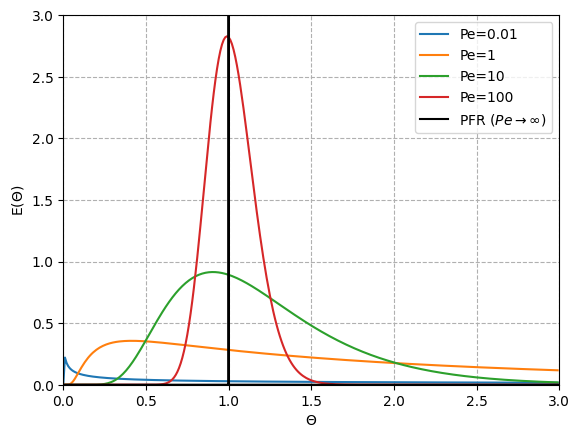

In [71]:
fig, ax = plt.subplots()

peclet = [0.01, 1, 10, 100]
for pe in peclet:
    a = rtdpy.AD_oo(tau=1, peclet=pe, dt=0.01, time_end=3)
    ax.plot(a.time, a.exitage, label=f"Pe={pe}")
# PFR
a = rtdpy.Pfr(tau=1, dt=0.001, time_end=3)
ax.plot(a.time, a.exitage, c='k', label=r"PFR ($Pe\rightarrow \infty$)")
ax.set_xlabel(r"$\Theta$")
ax.set_ylabel(r"E($\Theta$)")
ax.set_xlim(0, 3)
ax.set_ylim(0, 3)
ax.legend()
ax.grid(ls='--')
plt.show()

### large Peclet

$$E(t) = \frac{\sqrt{\text{Pe}}}{2\tau \sqrt{\pi}} \exp \left( - \frac{\text{Pe} (1-\Theta)^2}{4}\right)$$

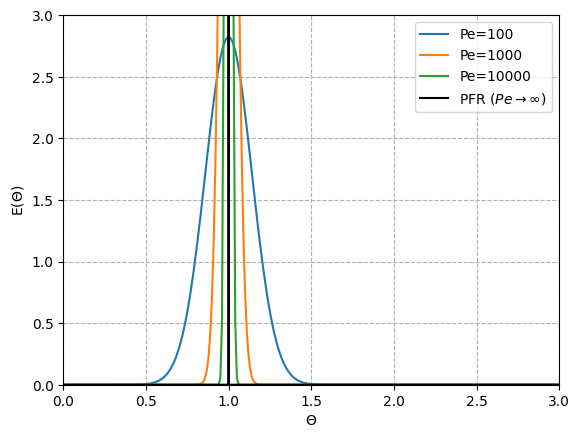

In [72]:
fig, ax = plt.subplots()

peclet = [100, 1000, 10000]
for pe in peclet:
    a = rtdpy.AD_hi_peclet(tau=1, peclet=pe, dt=0.01, time_end=3)
    ax.plot(a.time, a.exitage, label=f"Pe={pe}")
# PFR
a = rtdpy.Pfr(tau=1, dt=0.001, time_end=3)
ax.plot(a.time, a.exitage, c='k', label=r"PFR ($Pe\rightarrow \infty$)")
ax.set_xlabel(r"$\Theta$")
ax.set_ylabel(r"E($\Theta$)")
ax.set_xlim(0, 3)
ax.set_ylim(0, 3)
ax.legend()
ax.grid(ls='--')
plt.show()

## Combination of models

Se obtienen por operaciones de convolución:

$$(E_1 * E_2)(t^{\prime}) = \int_{0}^{\infty} E_1(t) \cdot E_2 \left( t - t^{\prime} \right) dt^{\prime}$$

$$(E_1 * E_2)(t^{\prime}) \approx \sum_{t=0}^{t} E_1(t) \cdot E_2 \left( t - t^{\prime} \right) \Delta t$$

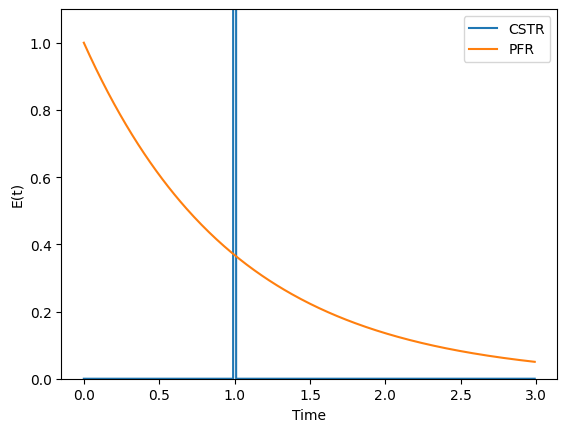

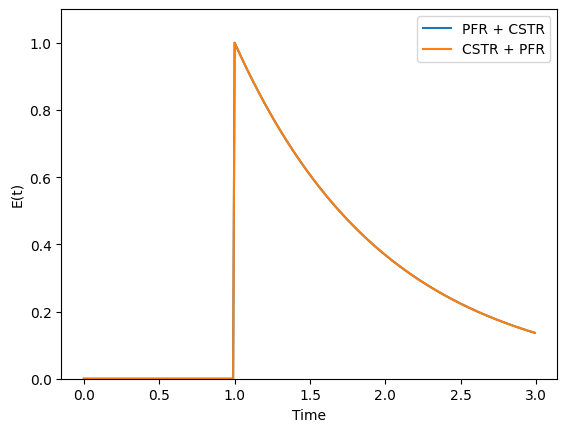

In [75]:
# curvas RTD
a = rtdpy.Pfr(tau=1, dt=.01, time_end=3)
b = rtdpy.Ncstr(tau=1, n=1, dt=.01, time_end=3)
c1 = rtdpy.Elist([a, b])
c2 = rtdpy.Elist([b, a])

# curvas individuales
fig, ax = plt.subplots()
ax.plot(a.time, a.exitage, label="CSTR")
ax.plot(b.time, b.exitage, label="PFR")
ax.set_ylim(0, 1.1)
plt.xlabel('Time')
plt.ylabel('E(t)')
ax.legend()
plt.show()


# curvas compuestas
fig, ax = plt.subplots()
ax.plot(c1.time, c1.exitage, label="PFR + CSTR")
ax.plot(c2.time, c2.exitage, label="CSTR + PFR")
ax.set_ylim(0, 1.1)
plt.xlabel('Time')
plt.ylabel('E(t)')
ax.legend()
plt.show()